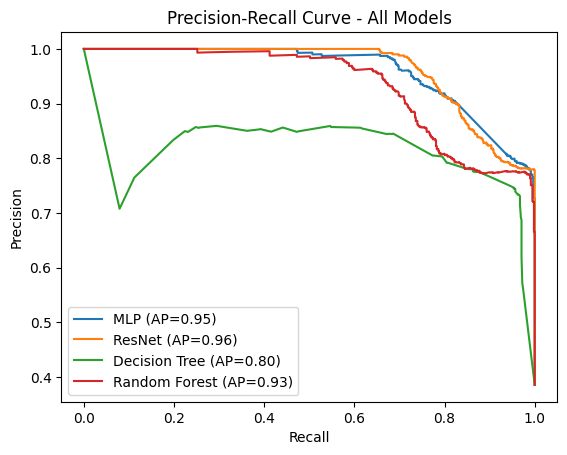

In [1]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

models = {
    "MLP":           ("preds/mlp_test_preds.npy",    "preds/mlp_test_labels.npy"),
    "ResNet":        ("preds/resnet_test_preds.npy",  "preds/resnet_test_labels.npy"),
    "Decision Tree": ("preds/dt_test_preds.npy",      "preds/dt_test_labels.npy"),
    "Random Forest": ("preds/rf_test_preds.npy",      "preds/rf_test_labels.npy"),
}

for name, (preds_path, labels_path) in models.items():
    preds = np.load(preds_path)
    labels = np.load(labels_path)
    precision, recall, _ = precision_recall_curve(labels, preds)
    ap = average_precision_score(labels, preds)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - All Models")
plt.legend()
plt.show()

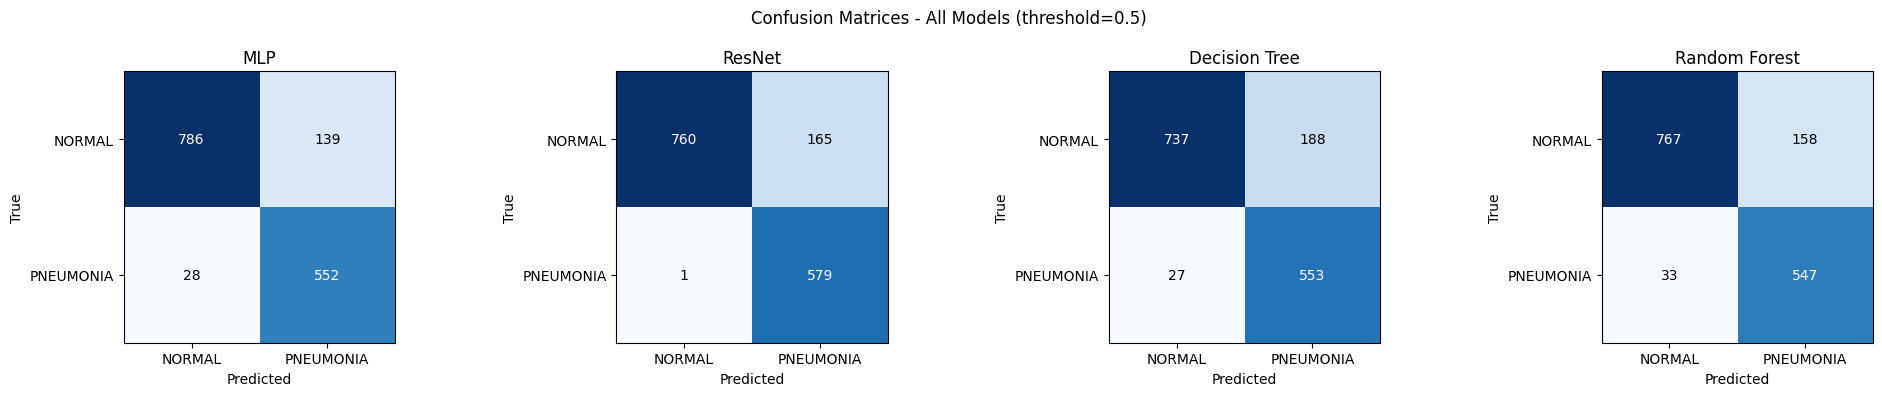

In [2]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

THRESHOLD = 0.5  # lower to e.g. 0.4 to catch more pneumonia cases

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (preds_path, labels_path)) in zip(axes, models.items()):
    preds = np.load(preds_path)
    labels = np.load(labels_path)
    cm = confusion_matrix(labels, (preds >= THRESHOLD).astype(int))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["NORMAL", "PNEUMONIA"])
    ax.set_yticklabels(["NORMAL", "PNEUMONIA"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.suptitle(f"Confusion Matrices - All Models (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

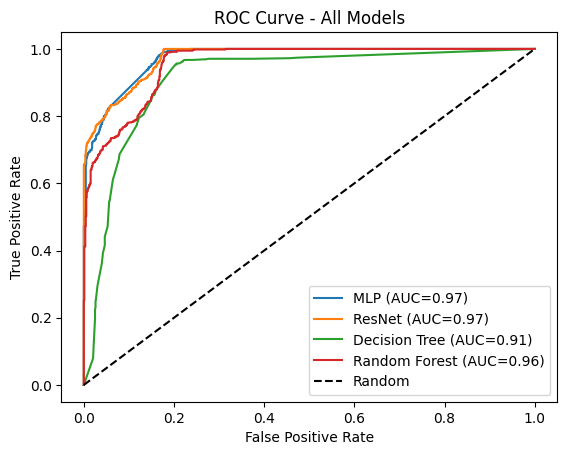

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score

for name, (preds_path, labels_path) in models.items():
    preds = np.load(preds_path)
    labels = np.load(labels_path)
    fpr, tpr, _ = roc_curve(labels, preds)
    auc = roc_auc_score(labels, preds)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.show()

In [4]:
from sklearn.metrics import classification_report
for name, (preds_path, labels_path) in models.items():
    preds = np.load(preds_path)
    labels = np.load(labels_path)
    print(f"\n{name} - Threshold: {THRESHOLD}")
    print(classification_report(
        labels.astype(int),
        (preds >= THRESHOLD).astype(int),
        target_names=["NORMAL", "PNEUMONIA"]
    ))


MLP - Threshold: 0.5
              precision    recall  f1-score   support

      NORMAL       0.97      0.85      0.90       925
   PNEUMONIA       0.80      0.95      0.87       580

    accuracy                           0.89      1505
   macro avg       0.88      0.90      0.89      1505
weighted avg       0.90      0.89      0.89      1505


ResNet - Threshold: 0.5
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.87       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91      0.89      0.89      1505


Decision Tree - Threshold: 0.5
              precision    recall  f1-score   support

      NORMAL       0.96      0.80      0.87       925
   PNEUMONIA       0.75      0.95      0.84       580

    accuracy                           0.86      1505
   macro avg       0.86      0.88      0.85      